# Business Insights & Visualization Dashboard
#### Author: Sachin Kumar B
#### Duration: Jan 2024 – Present

## Project Overview

#### This project showcases an end-to-end analytics workflow involving:
####    - Extraction of business data
####    - Data cleaning, transformation, and feature engineering
####    - Statistical analysis of KPIs
####    - Automated reporting
####    - Interactive visualization dashboard

#### This project represents a real-world scenario of analyzing large datasets and creating business-ready insights.

## Generate Database (If not Exists)

In [1]:
!python Generate_Database.py

business_data.db created successfully with 500 sample rows!


## Import Libraries

In [3]:
import os
import pandas as pd
import numpy as np
import sqlalchemy
import matplotlib.pyplot as plt
import plotly.express as px

## Load Data

In [4]:
# Check if database exists
db_path = "business_data.db"
if not os.path.exists(db_path):
    raise FileNotFoundError(
        f"❌ Database '{db_path}' not found. Please run the DB generation script first."
    )

# Create a SQLAlchemy engine (demo purpose)
engine = sqlalchemy.create_engine(f"sqlite:///{db_path}")

query = """
SELECT 
    order_id,
    customer_id,
    order_date,
    product,
    category,
    quantity,
    price,
    region
FROM sales_data;
"""

df = pd.read_sql(query, engine)

df.head()

,order_id,customer_id,order_date,product,category,quantity,price,region
0,1,7857,2024-01-26,Chair,Furniture,5,44684.30,West
1,2,9959,2024-07-01,Mouse,Electronics,6,17831.45,South
2,3,2075,2024-11-03,Pen,Stationery,9,15773.35,West
3,4,9749,2024-11-09,Notebook,Stationery,10,47082.99,Central
4,5,8396,2024-11-18,Laptop,Electronics,2,24126.71,South


## Data Cleaning & Transformation

In [5]:
# Convert date column
df["order_date"] = pd.to_datetime(df["order_date"])

# Handle missing values
df.fillna({
    "category": "Unknown",
    "region": "Unknown"
}, inplace=True)

# Feature Engineering
df["total_revenue"] = df["quantity"] * df["price"]
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()

df.head()


,order_id,customer_id,order_date,product,category,quantity,price,region,total_revenue,year,month
0,1,7857,2024-01-26,Chair,Furniture,5,44684.30,West,223421.50,2024,January
1,2,9959,2024-07-01,Mouse,Electronics,6,17831.45,South,106988.70,2024,July
2,3,2075,2024-11-03,Pen,Stationery,9,15773.35,West,141960.15,2024,November
3,4,9749,2024-11-09,Notebook,Stationery,10,47082.99,Central,470829.90,2024,November
4,5,8396,2024-11-18,Laptop,Electronics,2,24126.71,South,48253.42,2024,November


## Statistical Analysis & KPI Generation

In [6]:
# Main KPIs
total_revenue = df["total_revenue"].sum()
avg_order_value = df["total_revenue"].mean()
top_region = df.groupby("region")["total_revenue"].sum().idxmax()

print("=== Business KPIs ===")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Top Performing Region: {top_region}")

# Monthly Revenue Trend
monthly_trend = df.groupby("month")["total_revenue"].sum().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

monthly_trend


=== Business KPIs ===
Total Revenue: ₹63,288,658.01
Average Order Value: ₹126,577.32
Top Performing Region: South


month
January      8591931.52
February     4482448.02
March        5181110.25
April        5854656.10
May          3885497.29
June         4162429.70
July         6006485.00
August       4478027.27
September    5031602.43
October      4735421.28
November     6125309.20
December     4753739.95
Name: total_revenue, dtype: float64

## Automated Reporting

In [7]:
# Create KPI report
report = pd.DataFrame({
    "KPI": ["Total Revenue", "Average Order Value", "Top Performing Region"],
    "Value": [total_revenue, avg_order_value, top_region]
})

# Save report
report.to_csv("automated_business_report.csv", index=False)

print("Automated Report Saved: automated_business_report.csv")


Automated Report Saved: automated_business_report.csv


## Visualization for Strategic Decision-Making
### Monthly Revenue Trend – Matplotlib

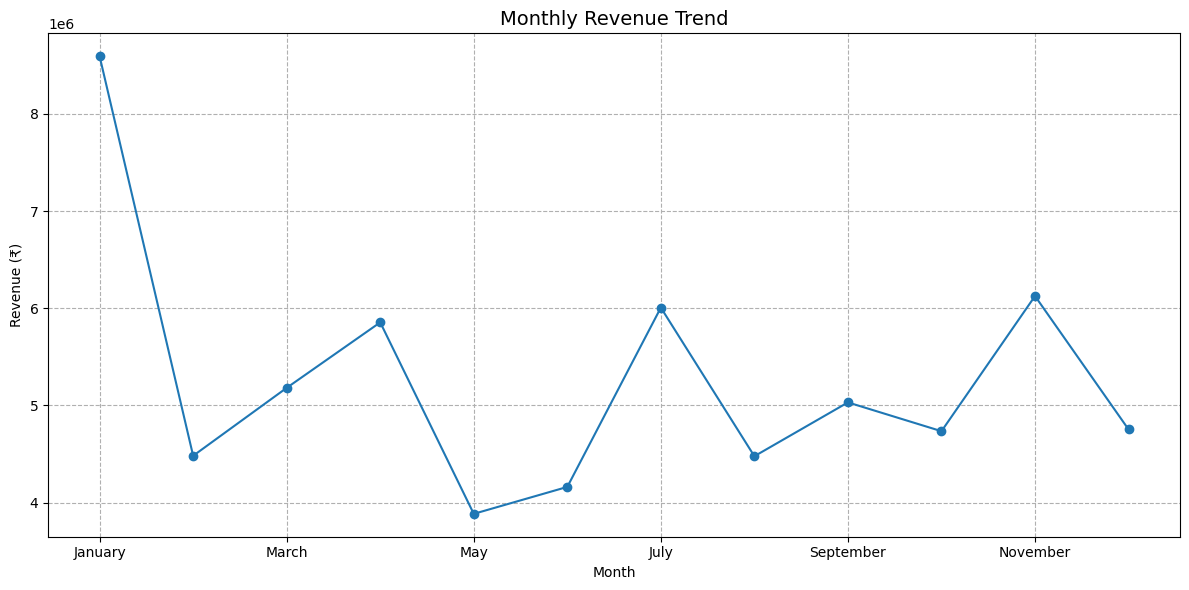

In [8]:
plt.figure(figsize=(12,6))
monthly_trend.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


### Revenue by Category – Plotly Interactive Dashboard

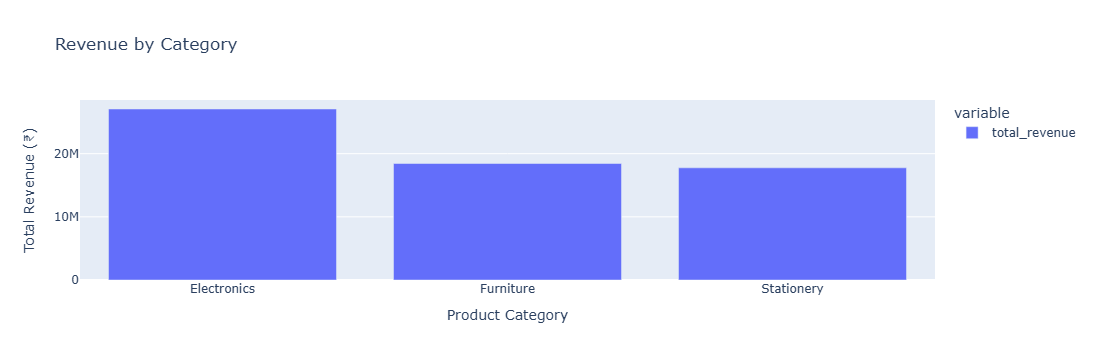

Dashboard Saved: category_revenue_dashboard.html


In [9]:
fig = px.bar(
    df.groupby("category")["total_revenue"].sum().sort_values(ascending=False),
    title="Revenue by Category",
    labels={"value": "Total Revenue (₹)", "category": "Product Category"},
)

fig.show()

# Save dashboard
fig.write_html("category_revenue_dashboard.html")
print("Dashboard Saved: category_revenue_dashboard.html")


## Summary & Conclusion

#### 1. Cleaned and transformed raw business data
#### 2. Generated actionable KPIs (Revenue, AOV, Region Performance)
#### 3. Built visual insights using both Matplotlib and Plotly
#### 4. Automated report and dashboard generation
#### 5. Delivered insights useful for decision-making